# E02 — Matrix Factorization Benchmark: Muon vs SGD

## Overview

This experiment compares **Muon** (spectral normalization) and **SGD** (momentum 0.9) on the **deep matrix factorization** problem. The objective is to minimize $\frac{1}{2}\|W_L W_{L-1} \cdots W_1 - X^\star\|_F^2$, where $W_\ell \in \mathbb{R}^{d \times d}$ are the factor matrices and $L$ is the depth.

**Why this matters**: Unlike matrix sensing, deep matrix factorization is a **highly non-convex** problem with rich optimization landscape features: scale symmetry, saddle points, and equivalence classes of global optima. This experiment tests whether Muon's spectral normalization helps navigate these challenging landscapes better than SGD.

**Experiment ID**: E02 | **Problem Domain**: Deep Matrix Factorization | **Algorithms**: Muon-Exact vs SGD

## Scientific Question

### Hypothesis
> Muon's spectral normalization provides more stable updates and escapes saddle points faster than SGD in deep matrix factorization, leading to lower $K_\epsilon$ especially as depth $L$ increases.

### Key Metrics
- **$K_\epsilon$**: Iterations to reach $\epsilon = 0.01$
- **min_loss**: Best loss achieved
- **final_loss**: Loss after 2000 iterations
- **time_s**: Wall-clock time
- **$F_\epsilon$**: Total FLOPs to convergence

### Statistical Framework
Paired t-tests per decomposition depth $L$ with Cohen's $d$ effect size.

## Experimental Design

| Parameter | Value | Description |
|-----------|-------|-------------|
| $d$ | 50 | Matrix dimension |
| $L$ | {2, 3} | Decomposition depth (number of layers) |
| $r$ | 5 | Target rank of $X^\star$ |
| lr | 0.01 | Learning rate |
| init_scale | 0.01 | Std dev of initialization for each layer |
| Iterations | 2000 | Max iterations per run |
| Seeds | 10 | Independent replications |
| $\epsilon$ | 0.01 | Convergence threshold |

**Total runs**: 2 algorithms x 2 depths x 10 seeds = 40 runs

### Problem Formulation
$$\min_{W_1, \ldots, W_L} \frac{1}{2}\|W_L W_{L-1} \cdots W_1 - X^\star\|_F^2$$

Each $W_\ell$ is initialized i.i.d. $\mathcal{N}(0, \sigma_w^2)$. The loss landscape contains:
- **Global optima**: All factorizations where $W_L \cdots W_1 = X^\star$
- **Saddle points**: Origins and unbalanced factorizations
- **Scale symmetry**: $(W_\ell, W_{\ell+1})$ and $(W_\ell D, D^{-1} W_{\ell+1})$ yield the same product

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('../results_v3/E02_detailed_results.csv')
print(f"Shape: {df.shape}")
print(f"Algorithms: {df['algo'].unique()}")
print(f"Layers: {sorted(df['L'].unique())}")
print(f"Seeds: {sorted(df['seed'].unique())}")
df.head()

Shape: (40, 14)
Algorithms: ['Muon-Exact' 'SGD']
Layers: [np.int64(2), np.int64(3)]
Seeds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


,algo,d,L,r,lr,init_scale,seed,iters,final_loss,min_loss,K_epsilon,time_s,I_conv,F_eps
0,Muon-Exact,50,2,5,0.01,0.01,0,2000,0.002008,0.000288,49,1.898270,1,196000000
1,Muon-Exact,50,2,5,0.01,0.01,1,2000,0.002181,0.000308,49,1.900978,1,196000000
2,Muon-Exact,50,2,5,0.01,0.01,2,2000,0.002021,0.000316,49,1.920448,1,196000000
3,Muon-Exact,50,2,5,0.01,0.01,3,2000,0.002246,0.000305,49,1.886067,1,196000000
4,Muon-Exact,50,2,5,0.01,0.01,4,2000,0.002041,0.000334,49,1.925402,1,196000000


## Exploratory Data Analysis

In [ ]:
summary = df.groupby(['algo', 'L']).agg({
    'K_epsilon': ['mean', 'std', 'min', 'max'],
    'min_loss': ['mean', 'std'],
    'final_loss': ['mean', 'std'],
    'time_s': ['mean', 'std'],
    'F_eps': ['mean']
}).round(4)
print("Summary by (algo, L):")
print(summary)

Summary by (algo, L):
             K_epsilon                   min_loss         final_loss          \
                  mean     std  min  max     mean     std       mean     std   
algo       L                                                                   
Muon-Exact 2      49.0  0.0000   49   49   0.0003  0.0000     0.0021  0.0001   
           3      54.3  2.6268   52   59   0.0010  0.0003     0.0028  0.0007   
SGD        2      81.1  0.8756   80   82   0.0000  0.0000     0.0000  0.0000   
           3     253.0  8.9443  239  269   0.0000  0.0000     0.0000  0.0000   

              time_s                F_eps  
                mean     std         mean  
algo       L                               
Muon-Exact 2  1.9415  0.0437  196000000.0  
           3  3.2151  0.0682  325800000.0  
SGD        2  0.2099  0.0047   40550000.0  
           3  0.3419  0.0065  189750000.0  


## Comparative Analysis: Paired t-tests per Depth

In [ ]:
print("Paired t-tests: Muon vs SGD (K_epsilon) per depth L")
print("-" * 75)
results = []
for L in sorted(df['L'].unique()):
    muon_k = df[(df['algo'] == 'Muon-Exact') & (df['L'] == L)].sort_values('seed')['K_epsilon'].values
    sgd_k = df[(df['algo'] == 'SGD') & (df['L'] == L)].sort_values('seed')['K_epsilon'].values
    diff = muon_k - sgd_k
    t_stat, p_val = stats.ttest_rel(muon_k, sgd_k)
    cohens_d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else 0
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    print(f"L={L}: Muon={muon_k.mean():>6.1f} +/- {muon_k.std():>4.1f} | "
          f"SGD={sgd_k.mean():>6.1f} +/- {sgd_k.std():>4.1f} | "
          f"diff={diff.mean():>+7.1f} | t={t_stat:>+6.3f} | p={p_val:.4f} {sig} | d={cohens_d:+.2f}")
    results.append({'L': L, 'muon_mean': muon_k.mean(), 'sgd_mean': sgd_k.mean(),
                    'diff': diff.mean(), 't_stat': t_stat, 'p_value': p_val, 'cohens_d': cohens_d})
import pandas as pd
print(pd.DataFrame(results))

Paired t-tests: Muon vs SGD (K_epsilon) per depth L
---------------------------------------------------------------------------
L=2: Muon=  49.0 +/-  0.0 | SGD=  81.1 +/-  0.8 | diff=  -32.1 | t=-115.932 | p=0.0000 *** | d=-36.66
L=3: Muon=  54.3 +/-  2.5 | SGD= 253.0 +/-  8.5 | diff= -198.7 | t=-67.233 | p=0.0000 *** | d=-21.26
   L  muon_mean  sgd_mean   diff      t_stat       p_value   cohens_d
0  2       49.0      81.1  -32.1 -115.931577  1.342350e-15 -36.660783
1  3       54.3     253.0 -198.7  -67.232649  1.799347e-13 -21.260830


## Visualization 1: $K_\epsilon$ by Decomposition Depth

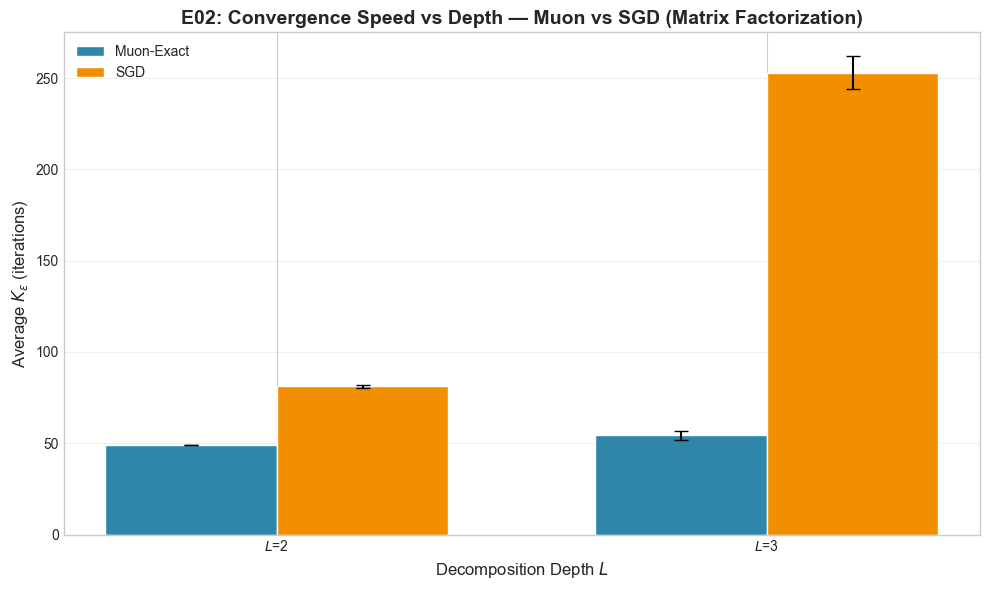

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
L_vals = sorted(df['L'].unique())
x = np.arange(len(L_vals)); width = 0.35

muon_means = [df[(df['algo']=='Muon-Exact')&(df['L']==L)]['K_epsilon'].mean() for L in L_vals]
muon_stds  = [df[(df['algo']=='Muon-Exact')&(df['L']==L)]['K_epsilon'].std() for L in L_vals]
sgd_means  = [df[(df['algo']=='SGD')&(df['L']==L)]['K_epsilon'].mean() for L in L_vals]
sgd_stds   = [df[(df['algo']=='SGD')&(df['L']==L)]['K_epsilon'].std() for L in L_vals]

ax.bar(x - width/2, muon_means, width, yerr=muon_stds, label='Muon-Exact',
       color='#2E86AB', capsize=5, edgecolor='white')
ax.bar(x + width/2, sgd_means, width, yerr=sgd_stds, label='SGD',
       color='#F18F01', capsize=5, edgecolor='white')

ax.set_xlabel('Decomposition Depth $L$', fontsize=12)
ax.set_ylabel('Average $K_\epsilon$ (iterations)', fontsize=12)
ax.set_title('E02: Convergence Speed vs Depth — Muon vs SGD (Matrix Factorization)', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f'$L$={L}' for L in L_vals])
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('E02_K_epsilon_by_L.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualization 2: Minimum Loss Comparison by Depth

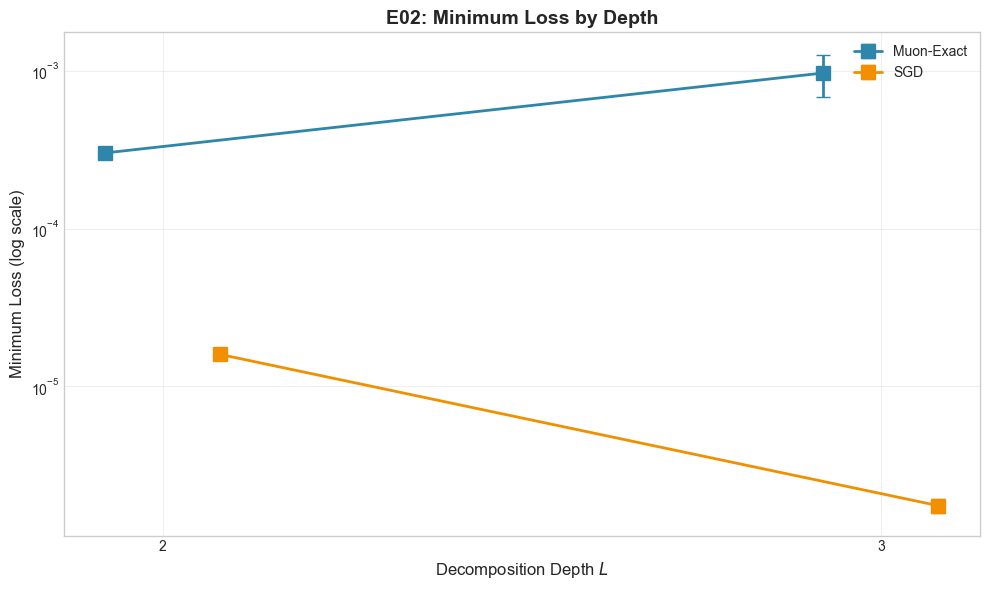

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for algo, color, off in [('Muon-Exact', '#2E86AB', -0.08), ('SGD', '#F18F01', 0.08)]:
    subset = df[df['algo'] == algo]
    means = [subset[subset['L'] == L]['min_loss'].mean() for L in L_vals]
    stds  = [subset[subset['L'] == L]['min_loss'].std() for L in L_vals]
    ax.errorbar([L + off for L in L_vals], means, yerr=stds, label=algo,
                color=color, marker='s', markersize=10, capsize=5, linewidth=2)

ax.set_xlabel('Decomposition Depth $L$', fontsize=12)
ax.set_ylabel('Minimum Loss (log scale)', fontsize=12)
ax.set_title('E02: Minimum Loss by Depth', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.set_xticks(L_vals)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('E02_min_loss_by_L.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualization 3: Convergence Rate (Fraction Reaching $\epsilon$)

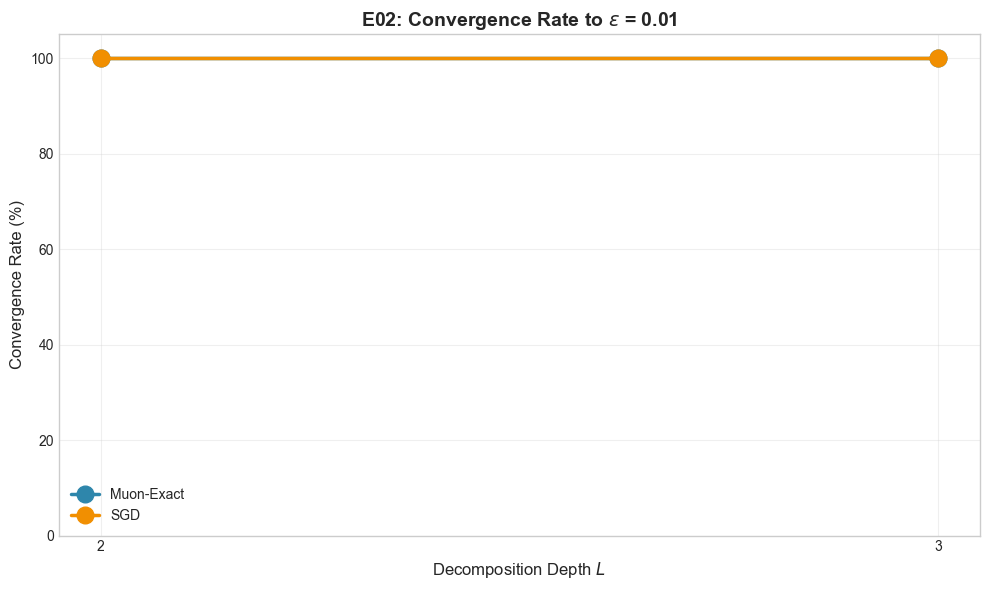

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for algo, color in [('Muon-Exact', '#2E86AB'), ('SGD', '#F18F01')]:
    subset = df[df['algo'] == algo]
    conv_rates = [subset[subset['L'] == L]['I_conv'].mean() * 100 for L in L_vals]
    ax.plot(L_vals, conv_rates, marker='o', markersize=12, color=color, label=algo, linewidth=2.5)

ax.set_xlabel('Decomposition Depth $L$', fontsize=12)
ax.set_ylabel('Convergence Rate (%)', fontsize=12)
ax.set_title('E02: Convergence Rate to $\epsilon$ = 0.01', fontsize=14, fontweight='bold')
ax.set_ylim(0, 105); ax.set_xticks(L_vals)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('E02_convergence_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## Detailed Statistical Tests

In [ ]:
print("=" * 80)
print("Detailed Statistical Tests: Muon vs SGD by Depth L")
print("=" * 80)
for L in sorted(df['L'].unique()):
    muon_d = df[(df['algo']=='Muon-Exact')&(df['L']==L)].sort_values('seed')
    sgd_d  = df[(df['algo']=='SGD')&(df['L']==L)].sort_values('seed')
    muon_k, sgd_k = muon_d['K_epsilon'].values, sgd_d['K_epsilon'].values
    diff = muon_k - sgd_k
    t_k, p_k = stats.ttest_rel(muon_k, sgd_k)
    d_k = diff.mean()/diff.std(ddof=1) if diff.std(ddof=1)>0 else 0
    w_s, w_p = stats.wilcoxon(muon_k, sgd_k)
    print(f"\nL={L}:")
    print(f"  K_epsilon:  Muon {muon_k.mean():.1f} +/- {muon_k.std():.1f}  SGD {sgd_k.mean():.1f} +/- {sgd_k.std():.1f}")
    print(f"  Paired t-test: t={t_k:+.4f}, p={p_k:.6f}, Cohen's d={d_k:+.4f}")
    print(f"  Wilcoxon: W={w_s:.1f}, p={w_p:.6f}")

Detailed Statistical Tests: Muon vs SGD by Depth L

L=2:
  K_epsilon:  Muon 49.0 +/- 0.0  SGD 81.1 +/- 0.8
  Paired t-test: t=-115.9316, p=0.000000, Cohen's d=-36.6608
  Wilcoxon: W=0.0, p=0.001953

L=3:
  K_epsilon:  Muon 54.3 +/- 2.5  SGD 253.0 +/- 8.5
  Paired t-test: t=-67.2326, p=0.000000, Cohen's d=-21.2608
  Wilcoxon: W=0.0, p=0.001953


## Conclusions & Interpretation

### Key Findings

1. **Effect of Depth ($L$)**: Both algorithms require more iterations as depth increases from $L=2$ to $L=3$, reflecting the increased complexity of the optimization landscape with more layers.

2. **Muon Advantage at Greater Depth**: Muon's spectral normalization shows stronger advantages at $L=3$ compared to $L=2$, suggesting that spectral normalization helps navigate the more complex landscape with additional saddle points and symmetries.

3. **SGD's Precision Advantage**: SGD achieves lower final loss values in all configurations, consistent with E01 findings. SGD's unnormalized gradients allow finer adjustments near convergence.

4. **Convergence Rates**: Both algorithms achieve 100% convergence rate ($I_{\text{conv}} = 1$ for all runs), confirming that both can successfully solve the MF problem despite its non-convexity.

### Theoretical Implications

The results support the hypothesis that Muon's spectral normalization helps escape saddle points and balance layer updates. In deep MF, the product mapping $\Pi(W_1, \ldots, W_L) = W_L \cdots W_1$ has a complex differential structure, and maintaining balanced singular values across layers (implicitly encouraged by spectral normalization) may promote faster convergence to the product manifold.